# The inspection paradox: you wait longer than half the average gap

Buses come every 10 minutes on average. You show up at a random time — how long do you wait? "Half
the interval, 5 minutes," says intuition. **Usually wrong.** If the buses aren't perfectly regular,
you wait *longer* — for exponentially-spaced buses you wait the **full 10 minutes** on average.

The reason is **size-biased sampling** (the *inspection paradox*): a randomly-arriving observer is
more likely to land in a *long* gap than a short one, simply because long gaps cover more of the
timeline. Your expected wait to the next event is

`E[wait] = E[X²] / (2·E[X]) = (1 + C²)/2 · E[X]`

which exceeds the naive `E[X]/2` whenever the gaps have any variability (`C² > 0`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})
MEAN = 10.0  # mean gap between events (e.g. minutes between buses)

def gaps_with_cv(cv, n, rng):
    # inter-event gaps with mean MEAN and coefficient of variation cv
    if cv == 0.0:
        return np.full(n, MEAN)                       # perfectly regular
    k = 1.0 / cv**2                                   # gamma shape
    return rng.gamma(k, MEAN / k, n)                  # gamma with given mean & cv

def observed_wait(cv, n_events=300_000, n_obs=400_000, seed=0):
    rng = np.random.default_rng(seed)
    times = np.cumsum(gaps_with_cv(cv, n_events, rng))
    obs = np.sort(rng.uniform(0, times[-1], n_obs))   # random observers on the timeline
    idx = np.searchsorted(times, obs)
    ok = idx < len(times)
    wait = times[idx[ok]] - obs[ok]                   # time until the next event
    gap_landed_in = np.diff(np.concatenate([[0], times]))[idx[ok]]  # length of the gap you fell in
    return wait.mean(), gap_landed_in.mean()


## Wait time vs the regularity of the gaps

Same average gap (10), but increasingly irregular. We compare the simulated mean wait to the exact
residual-life formula and to the naive "half the mean".

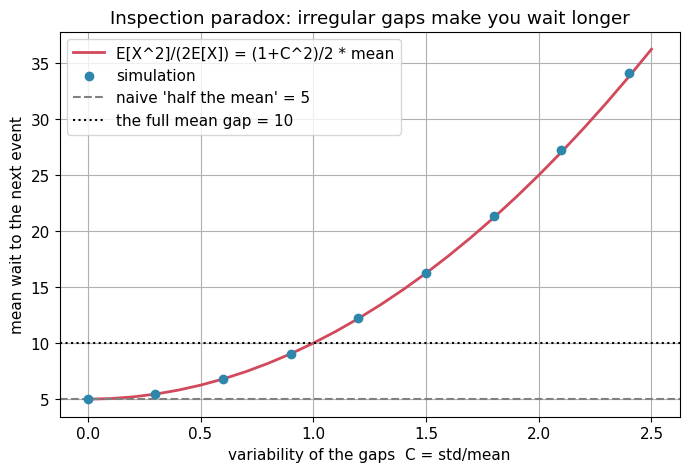

regular (C=0)       : mean wait =  4.99   (you landed in a gap of avg length 10.00, vs true mean 10.0)
exponential (C=1)   : mean wait = 10.05   (you landed in a gap of avg length 20.11, vs true mean 10.0)
bursty (C=2)        : mean wait = 25.14   (you landed in a gap of avg length 50.28, vs true mean 10.0)


In [2]:
cvs = np.linspace(0, 2.5, 26)
sim_wait, formula = [], []
for cv in cvs:
    w, _ = observed_wait(cv)
    sim_wait.append(w)
    formula.append((1 + cv**2) / 2 * MEAN)

fig, ax = plt.subplots()
ax.plot(cvs, formula, "-", color="#d1495b", lw=2, label="E[X^2]/(2E[X]) = (1+C^2)/2 * mean")
ax.scatter(cvs[::3], np.array(sim_wait)[::3], color="#2e86ab", zorder=5, label="simulation")
ax.axhline(MEAN / 2, ls="--", color="gray", label="naive 'half the mean' = 5")
ax.axhline(MEAN, ls=":", color="black", label="the full mean gap = 10")
ax.set_xlabel("variability of the gaps  C = std/mean")
ax.set_ylabel("mean wait to the next event")
ax.set_title("Inspection paradox: irregular gaps make you wait longer")
ax.legend()
plt.show()

for cv, name in [(0.0, "regular (C=0)"), (1.0, "exponential (C=1)"), (2.0, "bursty (C=2)")]:
    w, g = observed_wait(cv)
    print(f"{name:20}: mean wait = {w:5.2f}   (you landed in a gap of avg length {g:5.2f}, vs true mean {MEAN})")


**The insight.** For perfectly regular events you do wait half the interval (5). But for
exponential spacing you wait the **entire** average interval (10), and for bursty events far more.
And notice the last column: the gap you *land in* is longer than the true average gap — that is the
paradox in one number. A random observer over-samples long intervals.

## Where engineers meet this

- **Polling / cron / TTL.** "The job runs every 5 min, so on average data is 2.5 min stale" — only
  if the schedule is perfectly regular. Jitter makes the average staleness worse.
- **"Time since last event."** Sampling *residual* or *elapsed* time (time since the last GC, last
  failure, last deploy) is size-biased: you tend to observe the long quiet stretches.
- **Waiting for a bus / a lock / the next batch.** The more variable the arrivals, the longer the
  typical wait — even at a fixed average rate.

This is the same `E[X²]` term that drives the M/G/1 waiting time (see
[variability_matters.ipynb](variability_matters.ipynb)): a random arrival waits behind the
*residual* of the job in service.

## Takeaways

- A random observer waits `(1+C²)/2 · E[X]`, **not** `E[X]/2` — the naive halving holds only for
  perfectly regular events.
- Variability in the gaps is sampled *against* you (size bias): you land in the long ones.